<span style="color:red"> **Total Points 9** </span>

# Assignment based on the thickness estimation method by Farinotti & al 2009

> Farinotti, D., Huss, M., Bauder, A., Funk, M., & Truffer, M. (2009).
> A method to estimate the ice volume and ice-thickness distribution
> of alpine glaciers. Journal of Glaciology, 55(191), 422-430.

This code calculates the along-flow bed profile of Rhonegletscher
given 2007 data of glacier outline, surface and flowline coordinates.
For Rhonegletscher, absence of debris cover is assumed.

Coded by Fabian Walter & Mauro Werder (ETH-Zurich / WSL)

*Notes*:
- you can do this exercise in any programming language you like.
  - however, this script in Julia provides a very good scaffolding to solve this exercise.
    It's mostly reduced to fill-in a little of code the places marked with `...`
- remember to look at the introductory notebook we looked at in lecture 2
- plotting is done with [Plots.jl](https://docs.juliaplots.org/). I think that all needed commands are in the notebook, so you
  shouldn't need to look up the docs.

**Tasks** for you to complete are marked in **bold**.

**Task:** **Download and skim the manuscript by [Farinotti & al 2009](https://doi.org/10.3189/002214309788816759)**

Import packages which are needed for reading of files and plotting (hit shift+enter to execute the cell)

In [17]:
if !isfile("flowline_rhone_2007.txt")
    for (root, dirs, files) in walkdir(homedir())
        if "flowline_rhone_2007.txt" in files && !occursin(".ipynb_checkpoints", root)
            cd(root)
            break
        end
    end
end
println("Working directory: ", pwd())
using DelimitedFiles, Plots

Working directory: /home/jovyan/assignments/homework2


Define data file names and a function which can read Ascii-grids

In [18]:
fname_outl = "glacier_outline_rhone_2007.txt";
fname_flowl = "flowline_rhone_2007.txt";
fname_surfdem = "surface_dem_rhone_2007.asc";
fname_mask = "glacier_mask_rhone_2007.asc";

"""
    read_asc(fl)

Read a Ascii grid https://en.wikipedia.org/wiki/Esri_grid.

In:
- fn -- file name

Out
- array (rows/first-index correspond to x-dim, columns to y-dim)
- x,y

Note: there is no need for you to understand this function, just use it.
"""
function read_asc(fl)
    T = Float64
    io = open(fl, "r")
    toT = (io,T) -> parse(T, split(readline(io))[2])
    # read header
    nc, nr, xll, yll, dx = toT(io, Int), toT(io, Int), toT(io,Float64), toT(io,Float64), toT(io,Float64)
    prop, val = split(readline(io))

    # read body
    va = Array{T}(undef, nr, nc)
    tmp = split(read(io, String))
    if length(tmp)!=nc*nr
        error("Something's wrong with the file/stream $io.  It should contain $(nc*nr) values but has $(length(tmp))")
    end
    for i=1:nr, j=1:nc
        va[i,j] = parse(T, tmp[(i-1)*nc + j])
    end
    close(io)

    x = range(xll, step=dx, length=nc)
    y = range(yll, step=dx, length=nr)

    return rotr90(va), x, y
end

read_asc

Read in data:

In [19]:
outl = readdlm(fname_outl) # glacier outline
flowl = readdlm(fname_flowl,header=true)[1] # the central flow-line
fx, fy, f_surf, f_bed, f_width = flowl[:,1], flowl[:,2], flowl[:,3], flowl[:,4], flowl[:,5]
surfdem, x, y = read_asc(fname_surfdem) # the surface DEM
mask, x, y = read_asc(fname_mask) # the mask of the glacier
mask = convert(BitMatrix, mask); # make it into an array of Boolean
dx, dy = step(x), step(y) # the grid-spacing

(25.0, 25.0)

Calculate curvlinear, along flow coordinate, which starts
at glacier head and grows towards terminus:

In [20]:
s = zeros(size(flowl,1));
s[1] = 0;
for i=2:length(fx)
   s[i] = s[i-1] + sqrt( (fx[i]-fx[i-1])^2 + (fy[i]-fy[i-1])^2);
end

Plot of glacier bed and surface versus the along flow coordinate.
Glacier bed is known from radar and
considered as "ground truth" for our purposes:

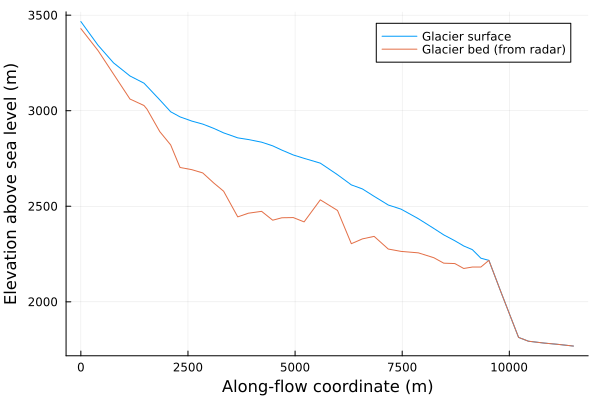

In [21]:
plot(s, f_surf, label="Glacier surface")
plot!(s, f_bed, label="Glacier bed (from radar)",
      xlabel="Along-flow coordinate (m)",ylabel="Elevation above sea level (m)")

Plot of glacier map with flow line and outline:

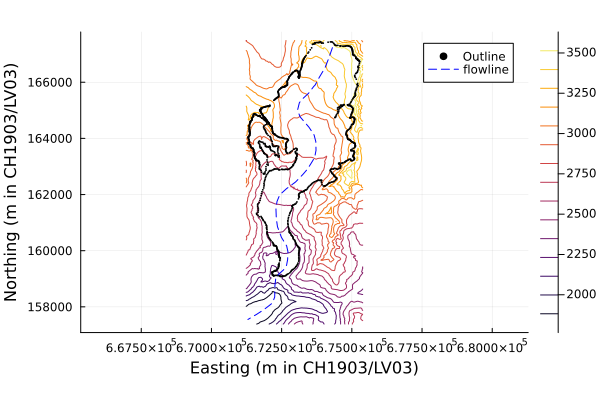

In [22]:
X, Y = x.+y'*0, x*0 .+y';
contour(x,y,surfdem', aspect_ratio=:equal, zlabel="ele")
scatter!(outl[:,1], outl[:,2], ls=:dot, ms=1, color=:black, label="Outline")
plot!(fx, fy, ls=:dash, color=:blue, label="flowline",
      xlabel="Easting (m in CH1903/LV03)", ylabel="Northing (m in CH1903/LV03)")

**Task 1:** **We need to determine the ELA of the apparent
mass balance. z_ela = 2870 is a good choice. Write
a short piece of code to support this value.
Use the values given below for the apparent mass balance
gradients `gacc` and `gabl`.**
**What value should `Btilde` approximate?**

Hints:
(0) fill in the `...` in below code-block
(1) write a function which calculates `btilde` for a `z` and a `z_ela`
(2) loop over all the points on the grid, if they are within the glacier (see
    `mask`) then sum their `btilde` to get `Btilde`.

### <span style="color:red"> **Points 2** </span>

In [23]:
gacc = 1.0*0.5*10^(-2); # apparent mass-balance gradient in accumulation zone
gabl = 1.0*0.9*10^(-2); # apparent mass-balance gradient in ablation zone
z_ela = 2870; # the "ELA" of the apparent mass-balance, i.e. the elevation where it is zero

 function btilde(z, gacc, gabl, z_ela)
     if z>z_ela
         return gacc*(z-z_ela)
     else
         return gabl*(z-z_ela)
     end
 end
 Btilde = 0.0
 for i = 1:length(surfdem)
     if mask[i]
         Btilde = Btilde + btilde(surfdem[i], gacc, gabl, z_ela)
     end
 end
 Btilde

235.35889999987566

In [24]:
for zz in 2800:10:2950
    b = 0.0
    for i = 1:length(surfdem)
        if mask[i]
            b = b + btilde(surfdem[i], gacc, gabl, zz)
        end
    end
    println(zz, "   ", b)
end

2800   10835.33170000006
2810   9356.314820000049
2820   7867.51978000001
2830   6368.739179999975
2840   4859.556660000034
2850   3336.629819999921
2860   1795.2929399999946
2870   235.35889999987566
2880   -1340.6944999999894
2890   -2927.733140000066
2900   -4525.3525400000135
2910   -6134.657700000055
2920   -7754.81402000006
2930   -9384.845900000038
2940   -11025.840579999905
2950   -12679.319859999865


Btilde should be about 0. The apparent mass balance is the mass balance corrected for the thickness change, so summed over the whole glacier it has to cancel out (like a glacier in steady state). With the loop above the sum changes sign between 2870 and 2880 m (about 235 at 2870 and about -1340 at 2880, compared to about ±10000 at 2800/2950), so 2870 is a good ELA.

Calculate volume flux. This requires integrating
the apparent mass balance over the contributing
glacier surface upstream of the coordinate. Identifying
the contributing surface is difficult to automate. Here we
simply assume that the contributing surface is at higher
elevations than the flowline coordinate.

In [25]:
function flux_at_z(z, z_ela)
    Q = 0.0
    for i = 1:length(surfdem)
        zz = surfdem[i]
        if mask[i] && zz>=z
            Q = Q + dx*dy* btilde(zz, gacc, gabl, z_ela)
        end
    end
    return Q
end
# Evaluate the volume flux for each flow-line point:
flux_at_z.(f_surf, z_ela)' ## note the ".": it applies the function to all elements of the input
                           # the ' is transpose, just to make more compact printing

1×41 adjoint(::Vector{Float64}) with eltype Float64:
 1.93513e6  4.70337e6  7.09346e6  …  1.47099e5  1.47099e5  1.47099e5

**Task 2:** **Can you think of a different (better) way to do above flux calculation or is this good enough?**

Your answer (double click to type):

Taking everything higher than the point is not really correct, because some of that area is in a different part of the glacier (other side, side branches, other basin over a ridge) and the ice from there doesn't actually flow through that cross section. Better would be to only use the area that actually drains through that point, e.g. split the glacier into catchments/ flowline segments with the DEM (ice flows down the surface slope) and only sum up the area upstream of the cross section. For the Rhone it's probably ok because it's mostly one long tongue, but for glaciers with many branches it would be off.

### <span style="color:red"> **Points 1** </span>

Now we want to apply equation (7) in Farinotti et al. (2009)

$H = \left( \frac{\bar q}{2 A}  \frac{n+2}{(C \rho g \tan(\alpha))^n} \right)^{1/(n+2)}$

We already have `qbar = Q/f_width`.  But we also need the surface slope `tan(alpha) = d z_s / d s`
(where `z_s` is the surface elevation and `s` the along flow line coordinate)

To calculate slope for each flowline grid point, we just take the mean of the forward
and backward finite difference to approximate the gradient.  This is a bit sloppy
but should be ok:

In [26]:
slope = zeros(length(s))
for i = 2:length(s)-1
    zabove,zmid,zbelow = f_surf[i-1:i+1]
    sabove,smid,sbelow = s[i-1:i+1]
    slope[i] = 1/2*( (zmid-zabove)/(smid-sabove) + (zbelow-zmid)/(sbelow-smid))
end
# special case start and end
slope[1] = (f_surf[2]-f_surf[1])/(s[2]-s[1])
slope[end] = (f_surf[end]-f_surf[end-1])/(s[end]-s[end-1])
slope' # the ' is transpose, just to make more compact printing

1×41 adjoint(::Vector{Float64}) with eltype Float64:
 -0.309321  -0.282157  -0.216913  …  -0.0236658  -0.0226783  -0.0247039

**Task 3:** **Plot the slope vs flow-line coordinate, together with the flow-line surface and bed topography:**

### <span style="color:red"> **Points 1** </span>

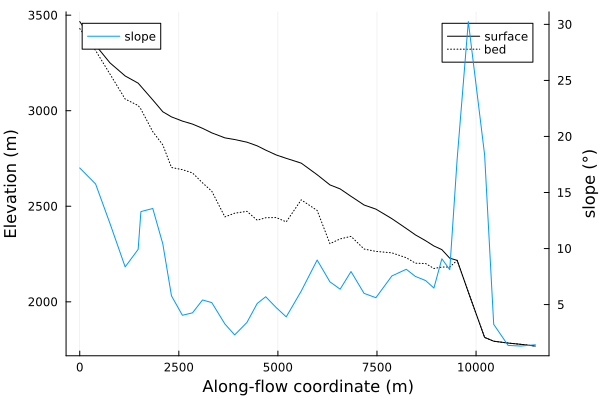

In [27]:
 plot(s, f_surf, color=:black, label="surface") # plot surface
 plot!(s, f_bed, color=:black, ls=:dot, ylabel="Elevation (m)", xlabel="Along-flow coordinate (m)", label="bed") # plot bed
 plot!(twinx(), s, atand.(-slope), label="slope", ylabel="slope (°)") # plot slope

Calculate thickness. Note that glacier width `f_width` was read off the map manually.
We only treat points where the flux Q is non-zero (below there is no more glacier).

**Task 3:**
### <span style="color:red"> **Points 3** </span>
- **fill the gaps marked with `...`**
- **Change the value of C to investigate (and report) the sensitivity of the thickness calculation.**
- **Plot glacier surface with bed from radar and bed from calculation, i.e. modify the first figure of this notebook.**

In [ ]:
# Constants
A = 2.4*10^(-15);
n = 3; 
C = 0.25; 
rho = 900;
g = 9.81;

# Loop over all points on the flow-line:
 Q = zeros(length(s));
 H = zeros(length(s));
 qbar = zeros(length(s));
 for i = 1:length(s)
     Q[i] = flux_at_z(f_surf[i], z_ela)
     if Q[i]<=0 || f_width[i]==0
         Q[i] = qbar[i] = H[i] = 0
         continue
     end
     # Ice volume flux
     qbar[i] = Q[i]/f_width[i]
     # Equation (7) in Farinotti et al. (2009)
     # (if you get a DomainError, you may need an `abs`
     H[i] = (qbar[i]/(2*A) * (n+2)/(C*rho*g*abs(slope[i]))^n)^(1/(n+2))
 end
 H'

1×41 adjoint(::Vector{Float64}) with eltype Float64:
 90.2644  105.758  133.512  172.114  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0

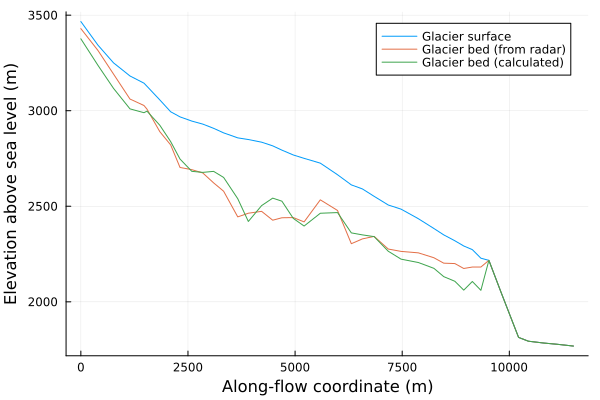

In [29]:
plot(s, f_surf, label="Glacier surface")
plot!(s, f_bed, label="Glacier bed (from radar)")
plot!(s, f_surf .- H, label="Glacier bed (calculated)",
      xlabel="Along-flow coordinate (m)",ylabel="Elevation above sea level (m)")

C = 0.1   max H = 742.9856856388783
C = 0.25   max H = 428.7621515046465
C = 0.5   max H = 282.87752537519367
C = 1.0   max H = 186.62956625621408


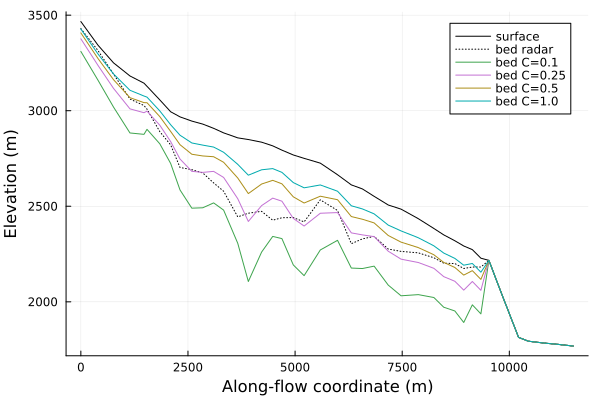

In [30]:
plot(s, f_surf, color=:black, label="surface")
plot!(s, f_bed, color=:black, ls=:dot, label="bed radar")
for c in [0.1, 0.25, 0.5, 1.0]
    hh = zeros(length(s))
    for i = 1:length(s)
        if Q[i] > 0
            hh[i] = (qbar[i]/(2*A) * (n+2)/(c*rho*g*abs(slope[i]))^n)^(1/(n+2))
        end
    end
    println("C = ", c, "   max H = ", maximum(hh))
    plot!(s, f_surf .- hh, label="bed C=$c")
end
plot!(xlabel="Along-flow coordinate (m)", ylabel="Elevation (m)")

Since H ~ C^(-n/(n+2)) = C^(-3/5), a bigger C gives a thinner glacier: doubling C makes H about 1.5x smaller. With C = 0.1 the max thickness is around 740 m, with 0.25 about 430 m, with 0.5 about 280 m and with 1 about 190 m (radar max is ~410 m). So the result depends a lot on C, but less than linearly. 0.25 fits the radar bed ok in the middle part but is too thick near the top and near the terminus.

**Task 4:** **Discuss how portable the approach by Farinotti & al 2009 is to other
glacier catchments. Is this a means to estimate glacier volumes for entire
mountain ranges, continents or the entire earth? If you challenge one or more
of the method's assumptions, then explain why this is a significant
shortcoming. Your answer should be concise and not exceed 15 sentences.**

Type your answer here:

In principle it's quite portable, you only need an outline, a DEM and some mass balance gradients, and those exist almost everywhere (RGI, satellite DEMs). That's why similar methods have actually been used for global glacier volume estimates. But a lot of the inputs are tuned. The mass balance gradients and especially C come from glaciers where you have radar data, and as we saw H depends quite strongly on C. C contains the basal sliding and the valley shape, which can be very different from one glacier to the next (warm-based glaciers in Alaska vs cold ones in the Arctic), so a single C for a whole mountain range is a big assumption. The method also assumes shallow ice / perfect plastic flow with only deformation. This doesnt work  for very steep, small glaciers, for ice caps and for tidewater glaciers where calving takes a big part of the mass loss. Debris cover also messes up the mass balance gradients, and it is common in the Himalaya. The flux calculation also gets bad for complex glaciers with lots of tributaries. Thus it's fine for an order-of-magnitude estimate over big regions, but the error for single glaciers can significant. For a reliable number you would still need some thickness measurements in each region to calibrate it.

### <span style="color:red"> **Points 2** </span>

Extra: We're still left with extrapolating our result back into 2D map-plane... but that
left as a *ungraded* exercise for the avid student.  Consult Farinotti & al 2009 on
how to go about this.

volume = 1.5967727888725796 km3,  mean H = 107.0043751966882 m


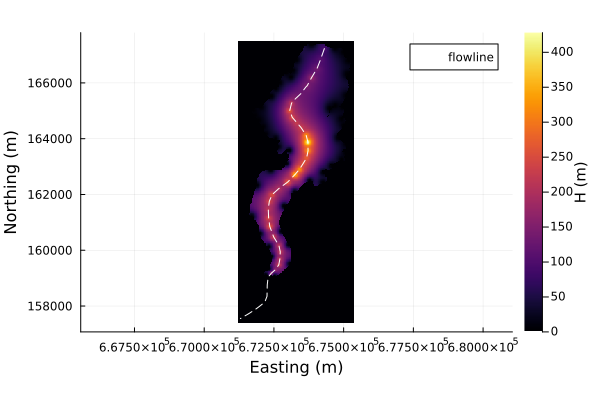

In [ ]:
#Since this was voluntary I used some AI to help me build it :)

px = [fx[H.>0]; outl[1:20:end,1]]
py = [fy[H.>0]; outl[1:20:end,2]]
ph = [H[H.>0]; zeros(length(outl[1:20:end,1]))]
hmap = zeros(size(surfdem))
for i = 1:length(x), j = 1:length(y)
    if mask[i,j]
        w = 1 ./ ((px .- x[i]).^2 .+ (py .- y[j]).^2 .+ 1)
        hmap[i,j] = sum(w.*ph)/sum(w)
    end
end
vol = sum(hmap)*dx*dy/1e9
println("volume = ", vol, " km3,  mean H = ", sum(hmap)/sum(mask), " m")
heatmap(x, y, hmap', aspect_ratio=:equal, colorbar_title="H (m)")
plot!(fx, fy, ls=:dash, color=:white, label="flowline",
      xlabel="Easting (m)", ylabel="Northing (m)")

Like in Farinotti et al. the thickness from the flowline is interpolated to the whole glacier with inverse distance weighting, and the outline is set to H = 0. I only took every 20th outline point, otherwise the outline has way more points than the flowline and everything becomes almost 0. Gives a volume of about 1.6 km³ and a mean thickness of about 107 m (glacier area about 14.9 km²).